In [28]:
import pandas as pd
import kagglehub
from src.dataloader import load_dataset
from house_prices.utils import extract_street_info
from src.preprocessing import target_encode, one_hot_encode
import re
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
# Load the dataset
path = kagglehub.dataset_download("debayank2024/house-price-prediction")
df = load_dataset(path)

Loading dataset from: /home/mordicus/.cache/kagglehub/datasets/debayank2024/house-price-prediction/versions/1/modified_data.csv


In [30]:
df.head(5)

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,price_per_sqft
0,2014-05-02,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,233.58
1,2014-05-02,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,653.15
2,2014-05-02,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,177.20
3,2014-05-02,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,210.00
4,2014-05-02,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,283.51


In [31]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            4600 non-null   str    
 1   price           4600 non-null   float64
 2   bedrooms        4600 non-null   float64
 3   bathrooms       4600 non-null   float64
 4   sqft_living     4600 non-null   int64  
 5   sqft_lot        4600 non-null   int64  
 6   floors          4600 non-null   float64
 7   waterfront      4600 non-null   int64  
 8   view            4600 non-null   int64  
 9   condition       4600 non-null   int64  
 10  sqft_above      4600 non-null   int64  
 11  sqft_basement   4600 non-null   int64  
 12  yr_built        4600 non-null   int64  
 13  yr_renovated    4600 non-null   int64  
 14  street          4600 non-null   str    
 15  city            4600 non-null   str    
 16  statezip        4600 non-null   str    
 17  price_per_sqft  4600 non-null   float64
dtyp

The dataset does not have missing values.

In [32]:
df['date'] = pd.to_datetime(df['date'])

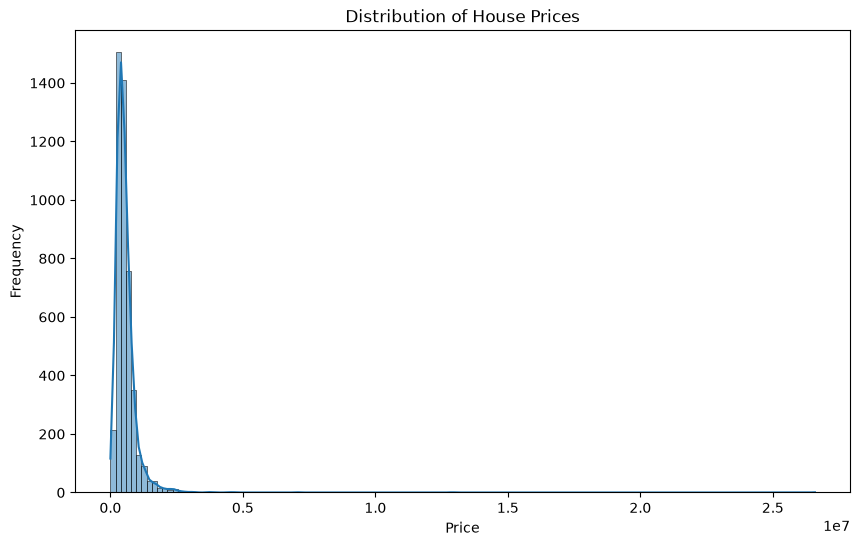

In [33]:
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], kde=True)
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

The distribution of prices is higly skewed to the right. This will require log-transformation.

Plot prices over time. What is the timeline of samples? Is there a seasonal trend? (e.g., do prices spike in summer?). This helps decide what should be extracted. 

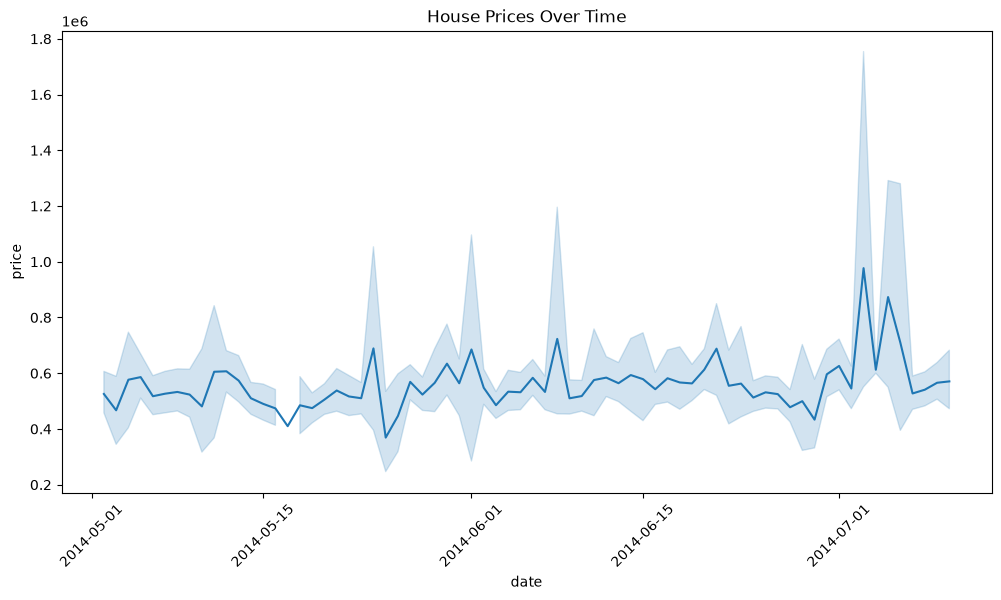

In [34]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='date', y='price')
plt.title('House Prices Over Time')
plt.xticks(rotation=45)
plt.show()

Given the short span, extract days.

<Axes: xlabel='date'>

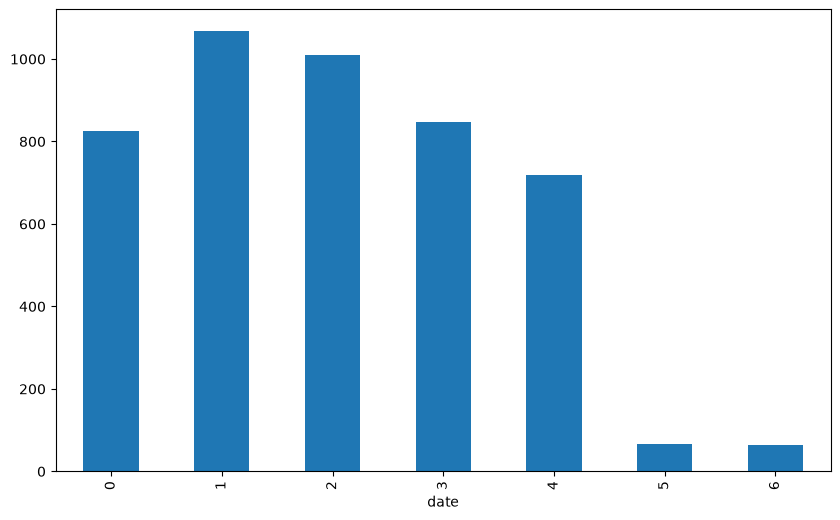

In [35]:
df['date'].dt.weekday.value_counts().sort_index().plot(kind='bar', figsize=(10, 6))

In [36]:
# Extracting the weekday from the 'date' column
df['weekday'] = df['date'].dt.weekday

In [37]:
# Extracting the number of days since the first date in the dataset
df['days_since_first'] = (df['date'] - df['date'].min()).dt.days

In [38]:
# Drop the original 'date' column if it's no longer needed
df.drop(columns=['date'], inplace=True)

Proceed on geographic information in the data and prepare for encoding.

In [39]:
for col in ['street', 'city', 'statezip']:
    print(f"{col} cardinality: {df[col].nunique()}")

street cardinality: 4525
city cardinality: 44
statezip cardinality: 77


street-column has high cardinality and is useless as such.

In [40]:
# Define common US street suffixes
# We use \b to ensure we match whole words and [A-Za-z] to capture the letters
suffixes = [
    'Ave', 'Avenue', 'St', 'Street', 'Blvd', 'Boulevard', 
    'Dr', 'Drive', 'Ln', 'Lane', 'Ct', 'Court', 'Way', 
    'Ter', 'Terrace', 'Cir', 'Circle', 'Pl', 'Place', 
    'Rd', 'Road', 'Parkway', 'Trace', 'Trail'
]

# Create a regex pattern: \b(Ave|Avenue|St|Street|...)\b
# We sort by length descending to ensure "Avenue" is matched before "Ave"
suffixes.sort(key=len, reverse=True)
pattern = r'\b(' + '|'.join(map(re.escape, suffixes)) + r')\b'


In [41]:
# Apply the extraction
df[['street_name', 'street_type']] = df['street'].apply(
    lambda x: pd.Series(extract_street_info(pattern = pattern, street_name = x))
)

# Define the canonical mapping. This maps abbreviations to their full, standard names
suffix_mapping = {
    'Ave': 'Avenue',
    'Avenue': 'Avenue',
    'St': 'Street',
    'Street': 'Street',
    'Blvd': 'Boulevard',
    'Boulevard': 'Boulevard',
    'Dr': 'Drive',
    'Drive': 'Drive',
    'Ln': 'Lane',
    'Lane': 'Lane',
    'Ct': 'Court',
    'Court': 'Court',
    'Rd': 'Road',
    'Road': 'Road',
    'Pl': 'Place',
    'Place': 'Place',
    'Cir': 'Circle',
    'Circle': 'Circle',
    'Ter': 'Terrace',
    'Terrace': 'Terrace',
    'Way': 'Way',
    'Tr': 'Trace',
    'Trail': 'Trail'
}

#Normalize the extracted street_type
# This replaces the extracted value with the canonical name
df['street_type'] = df['street_type'].map(suffix_mapping).fillna(df['street_type'])

# Check the new distribution
print("Street Type Distribution:")
print(df['street_type'].value_counts())

# Show a few examples
print("\nSample of extracted data:")
print(df[['street', 'street_name', 'street_type']].head(10))

Street Type Distribution:
street_type
Avenue       1949
Street       1167
Place         806
Court         174
Way           155
Drive         123
Road           69
Lane           53
Other          37
Boulevard      32
Terrace        14
Trail          13
Circle          8
Name: count, dtype: int64

Sample of extracted data:
                     street           street_name street_type
0      18810 Densmore Ave N        18810 Densmore      Avenue
1           709 W Blaine St          709 W Blaine      Street
2  26206-26214 143rd Ave SE     26206-26214 143rd      Avenue
3           857 170th Pl NE             857 170th       Place
4         9105 170th Ave NE            9105 170th      Avenue
5            522 NE 88th St           522 NE 88th      Street
6         2616 174th Ave NE            2616 174th      Avenue
7         23762 SE 253rd Pl        23762 SE 253rd       Place
8   46611-46625 SE 129th St  46611-46625 SE 129th      Street
9          6811 55th Ave NE             6811 55th      

In [42]:
# Drop the original 'street' and 'street_name' columns
df.drop(columns=['street', 'street_name'], inplace=True)

state, city and zip provide useful geographic information but need to be encoded.

In [43]:
# Split statezip into state and zip columns
df[['state', 'zip']] = df['statezip'].str.split(' ', expand=True)

Count unique values in state, city and zip for the purposes of encoding.

In [44]:
df['state'].unique().value_counts().sum()

np.int64(1)

state is clearly useless.

In [45]:
df['city'].unique().value_counts().sum()

np.int64(44)

In [46]:
df['zip'].unique().value_counts().sum()

np.int64(77)

In [47]:
df.drop(columns=['statezip', 'state'], inplace=True)

Identify "hot" geographic areas or neighborhoods that drive up prices. 

In [48]:
df.groupby(['city', 'zip'])['price'].mean().sort_values(ascending=False).describe()#.head(10)

count    1.030000e+02
mean     5.213619e+05
std      2.911518e+05
min      2.072880e+05
25%      3.085412e+05
50%      4.481250e+05
75%      6.317129e+05
max      2.046559e+06
Name: price, dtype: float64

In [49]:
# Check if zip codes are unique to cities
is_zip_unique = df.groupby('zip')['city'].nunique().max() == 1
print(f"Is zip unique to city? {is_zip_unique}")


Is zip unique to city? False


In [50]:
# Create a new column that combines city and zip for better granularity
df['cityzip'] = df['city'] + "_" + df['zip']
# Drop the original city and zip columns if desired
df.drop(columns=['city', 'zip'], inplace=True)


The above suggest that target encoding is the best choice, given that there is (just) over 100 categories.

In [51]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   price             4600 non-null   float64
 1   bedrooms          4600 non-null   float64
 2   bathrooms         4600 non-null   float64
 3   sqft_living       4600 non-null   int64  
 4   sqft_lot          4600 non-null   int64  
 5   floors            4600 non-null   float64
 6   waterfront        4600 non-null   int64  
 7   view              4600 non-null   int64  
 8   condition         4600 non-null   int64  
 9   sqft_above        4600 non-null   int64  
 10  sqft_basement     4600 non-null   int64  
 11  yr_built          4600 non-null   int64  
 12  yr_renovated      4600 non-null   int64  
 13  price_per_sqft    4600 non-null   float64
 14  weekday           4600 non-null   int32  
 15  days_since_first  4600 non-null   int64  
 16  street_type       4600 non-null   str    
 17  cityzi

In [52]:
# Encode categorical variables using target encoding for 'cityzip' and one-hot encoding for 'street_type'
df, _ = target_encode(df, 'cityzip', 'price')
# Drop the 'cityzip' column after encoding 
df.drop(columns=['cityzip'], inplace=True)
# Encode 'street_type' using one-hot encoding
df, _ = one_hot_encode(df, 'street_type')

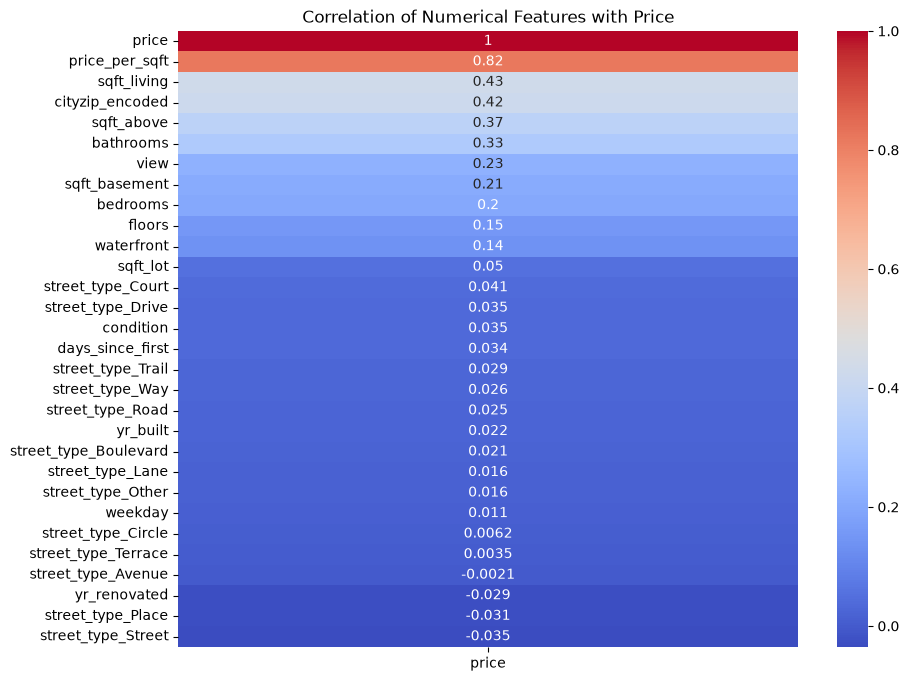

Top correlations with price:
price                    1.000000
price_per_sqft           0.819279
sqft_living              0.430410
cityzip_encoded          0.419899
sqft_above               0.367570
bathrooms                0.327110
view                     0.228504
sqft_basement            0.210427
bedrooms                 0.200336
floors                   0.151461
waterfront               0.135648
sqft_lot                 0.050451
street_type_Court        0.041168
street_type_Drive        0.035433
condition                0.034915
days_since_first         0.033906
street_type_Trail        0.028693
street_type_Way          0.025999
street_type_Road         0.025070
yr_built                 0.021857
street_type_Boulevard    0.021013
street_type_Lane         0.016303
street_type_Other        0.015872
weekday                  0.010847
street_type_Circle       0.006226
street_type_Terrace      0.003547
street_type_Avenue      -0.002142
yr_renovated            -0.028774
street_type_Place  

In [53]:
# Correlation Analysis
# Select numerical columns for correlation
numerical_df = df.select_dtypes(include=['number'])
correlation_matrix = numerical_df.corr()

# Visualize the correlation with 'price'
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix['price'].sort_values(ascending=False).to_frame(), annot=True, cmap='coolwarm')
plt.title('Correlation of Numerical Features with Price')
plt.show()

# Print top correlations
print("Top correlations with price:")
print(correlation_matrix['price'].sort_values(ascending=False))